In [3]:
!pip install matplotlib seaborn scikit-learn python-igraph portion

  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached portion-2.6.1-py3-none-any.whl.metadata (34 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached igraph-1.0.0-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (4.4 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
Using cached m

 Reading: qubo_lhs_terms.txt
 Found 155469 unique terms
💾 Saved: QUBO_matrix.txt (675x675, 3.6 MB)
📊 Non-zeros: 310,263 (68.096%)
🔢 Range: -0.500 to 6.870


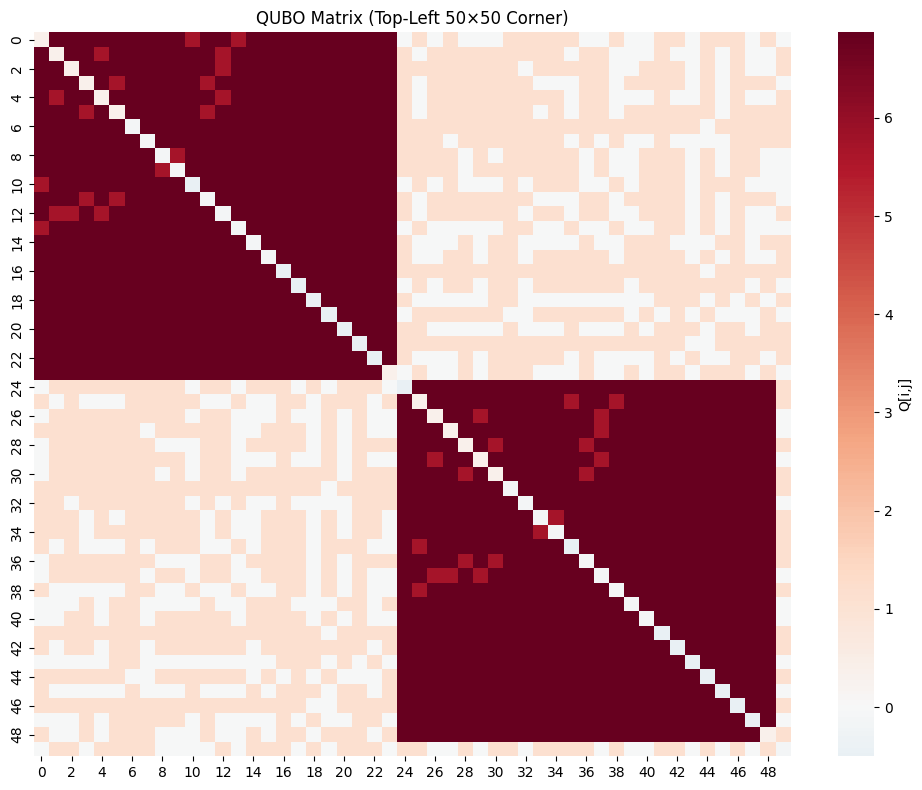


🎯 QUBO_matrix.txt ready for Pyomo solver!
Next: Run your Pyomo code with n=675


In [4]:
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def polynomial_to_qubo_matrix(file_path="qubo_lhs_terms.txt", output_path="QUBO_matrix.txt", n_vars=675):
    """Convert polynomial QUBO terms to dense symmetric matrix"""
    
    # Verify input file exists
    if not Path(file_path).exists():
        raise FileNotFoundError(f" {file_path} not found! Check filename/path.")
    
    print(f" Reading: {file_path}")
    Q = np.zeros((n_vars, n_vars))
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Robust regex: handles ALL formats from your file
    # 1. "13.740 * x_153 * x_152" 
    # 2. "13.740 x153 x152" 
    # 3. "Term X: coeff * xNUM * xNUM"
    pattern1 = r'([-+]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*\*?\s*x[_]?(\d+)\s*\*?\s*x[_]?(\d+)'
    terms1 = re.findall(pattern1, content)
    
    # Fallback pattern for simpler formats
    pattern2 = r'([-+]?\d*\.?\d+)\s*x(\d+)\s*x(\d+)'
    terms2 = re.findall(pattern2, content)
    
    # Combine and deduplicate
    all_terms = list(set(terms1 + terms2))
    print(f" Found {len(all_terms)} unique terms")
    
    if len(all_terms) == 0:
        print(" No terms found. File format may not match expected pattern.")
        return None

    skipped = 0
    for coeff_str, i_str, j_str in all_terms:
        coeff = float(coeff_str)
        i, j = int(i_str)-1, int(j_str)-1  # 0-based
        
        if i >= n_vars or j >= n_vars:
            skipped += 1
            continue
            
        if i == j:
            Q[i, j] += coeff
        else:
            Q[i, j] += coeff / 2.0
            Q[j, i] += coeff / 2.0
    
    # Save matrix
    np.savetxt(output_path, Q, fmt='%.6f')
    
    # Statistics
    nz = np.count_nonzero(Q)
    print(f"💾 Saved: {output_path} ({n_vars}x{n_vars}, {Q.nbytes/1e6:.1f} MB)")
    print(f"📊 Non-zeros: {nz:,} ({nz/(n_vars**2)*100:.3f}%)")
    print(f"🔢 Range: {Q.min():.3f} to {Q.max():.3f}")
    if skipped > 0:
        print(f"⏭️ Skipped {skipped} out-of-bounds terms")
    
    return Q

# RUN CONVERSION (Fixed filename!)
Q = polynomial_to_qubo_matrix("qubo_lhs_terms.txt", "QUBO_matrix.txt", n_vars=675)

if Q is not None:
    plt.figure(figsize=(10,8))
    sns.heatmap(Q[:50, :50], cmap='RdBu_r', center=0, cbar_kws={'label': 'Q[i,j]'})
    plt.title('QUBO Matrix (Top-Left 50×50 Corner)')
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 QUBO_matrix.txt ready for Pyomo solver!")
    print("Next: Run your Pyomo code with n=675")


In [ ]:
import numpy as np
from pyomo.environ import *
from scipy.sparse import csr_matrix, find

# 1. Load and prepare sparse data efficiently
Q_dense = np.loadtxt("QUBO_matrix.txt", dtype=float)
n = Q_dense.shape[0]

# Use CSR matrix to efficiently handle non-zeros
Q_sparse = csr_matrix(Q_dense)
rows, cols, vals = find(Q_sparse)

# 2. Build the Pyomo Model
model = ConcreteModel(name="QUBO_Model")
model.I = RangeSet(0, n-1)
model.x = Var(model.I, domain=Binary)

# 3. Optimized Objective using quicksum
def qubo_objective(model):
    # Use quicksum instead of sum() for better performance
    return quicksum(vals[k] * model.x[rows[k]] * model.x[cols[k]] 
                    for k in range(len(vals)))

model.obj = Objective(rule=qubo_objective, sense=minimize)

# 4. Solve with SCIP
solver = SolverFactory("scip")

# Optional: Add solver-specific parameters to speed up solution finding
# result = solver.solve(model, tee=True, timelimit=300) 
result = solver.solve(model, tee=True) # Set tee=True to see real-time progress

# 5. Output results
if result.solver.termination_condition == TerminationCondition.optimal:
    print(f"Objective Value: {value(model.obj)}")
else:
    print(f"Solver Status: {result.solver.termination_condition}")


SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.1           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.1           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.88.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.7.0          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 4.0.4 

In [14]:
# ============================================================================
# 6. DETAILED SOLUTION ANALYSIS (Run AFTER solver.solve())
# ============================================================================

print("\n" + "="*80)
print("COMPLETE SOLUTION DETAILS")
print("="*80)

# Full model display (exactly like your example)
print("\n FULL MODEL STATE:")
model.display()

# Detailed binary solution extraction
print("\n BINARY SOLUTION:")
binary_solution = [int(round(value(model.x[j]))) for j in model.I]
solution_str = ''.join(map(str, binary_solution))
active_indices = [j for j in model.I if binary_solution[j] == 1]

print(f"Binary vector:  {solution_str}")
print(f"Active vars:    {len(active_indices)}/{n} ({100*len(active_indices)/n:.1f}%)")
print(f"1's positions:  {active_indices}")
print(f"Objective:      {value(model.obj):.6f}")





🏆 COMPLETE SOLUTION DETAILS

📊 FULL MODEL STATE:
Model QUBO_Model

  Variables:
    x : Size=675, Index=I
        Key : Lower : Value                  : Upper : Fixed : Stale : Domain
          0 :     0 :                   -0.0 :     1 : False : False : Binary
          1 :     0 :                   -0.0 :     1 : False : False : Binary
          2 :     0 :                   -0.0 :     1 : False : False : Binary
          3 :     0 :                   -0.0 :     1 : False : False : Binary
          4 :     0 :                   -0.0 :     1 : False : False : Binary
          5 :     0 :                   -0.0 :     1 : False : False : Binary
          6 :     0 :                    0.0 :     1 : False : False : Binary
          7 :     0 :                    0.0 :     1 : False : False : Binary
          8 :     0 :                    0.0 :     1 : False : False : Binary
          9 :     0 :                    0.0 :     1 : False : False : Binary
         10 :     0 :              

In [13]:
# ============================================================================
# STRONG BINARY VALUES (x[j] = 1.0 positions)
# ============================================================================

print("\n" + "="*50)
print(" STRONG BINARY VALUES (x[j] = 1)")
print("="*50)

# Get ALL strong binary positions
strong_indices = [j for j in model.I if value(model.x[j]) > 0.99]  # Exactly 1.0
binary_vector = [int(round(value(model.x[j]))) for j in model.I]

print(f"✅ Total strong vars: {len(strong_indices)} / {n}")
print(f"Positions: {strong_indices}")
print(f"Full binary:  {''.join(map(str, binary_vector))}")
print(f"Density:     {100*len(strong_indices)/n:.1f}%")





🔥 STRONG BINARY VALUES (x[j] = 1)
✅ Total strong vars: 18 / 675
Positions: [22, 35, 63, 85, 120, 233, 258, 304, 337, 368, 394, 419, 457, 474, 522, 524, 620, 650]
Full binary:  000000000000000000000010000000000001000000000000000000000000000100000000000000000000010000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000100000000000000000000000000000000000000000000010000000000000000000000000000000010000000000000000000000000000001000000000000000000000000010000000000000000000000001000000000000000000000000000000000000010000000000000000100000000000000000000000000000000000000000000000101000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000001000000000000000000000000
Density:     2.7%
